### Notebook for Pulsar Lightcurves

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.io import fits
from astroquery.fermi import FermiLAT
from astroquery.esasky import ESASky
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
import astropy.units as u
import warnings

/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astroquery/fermi/__init__.py:37: UserWarning: Experimental: Fermi-LAT has not yet been refactored to have its API match the rest of astroquery.
  warnings.warn("Experimental: Fermi-LAT has not yet been refactored to have "


Mission,Table,Table Description
str16,str12,str80
AGILE,agilecat,First AGILE Catalog of High-Confidence Gamma-Ray Sources
AGILE,agileupvar,Updated AGILE Catalog of Bright Gamma-Ray Sources and Variability
AKARI,akaribsc,"AKARI/FIS All-Sky Survey Bright Source Catalog, Version 1"
AKARI,akaripsc,"AKARI/IRC All-Sky Survey Point Source Catalog, Version 1"
ANS,ansuvpscat,ANS Ultraviolet Photometry Catalog of Point Sources
ARIEL V,ariel3a,3rd Ariel-V SSI Catalog
ARIEL V,ariel5,Ariel V All-Sky Monitor
ASCA,ascaegclus,ASCA Elliptical Galaxies and Galaxy Clusters Catalog
ASCA,ascagis,ASCA GIS Source Catalog (AMSS-I + AMSS-II)


In [105]:
from astroquery.heasarc import Heasarc
import requests
from astropy.table import Table

heasarc = Heasarc()

target_name = "Vela X-1"
mission = 'xmmstack'

simbad = Simbad()
simbad_data = simbad.query_object(target_name)

print("Coordinates from Simbad:", simbad_data)

ra, dec = simbad_data['RA'][0], simbad_data['DEC'][0]
coords = SkyCoord(ra, dec, unit=(u.hourangle, u.deg),frame= 'icrs' )

# Get the query payload to see what the request looks like
payload = heasarc.query_region(coords, mission=mission, radius='1 degree', get_query_payload=True)
print("Payload:", payload)

response = heasarc.query_object_async(target_name, mission=mission, displaymode='URL')
print("Data URL:", response.url) 

responseurl = requests.get(response.url)

# Save the file to disk
with open("vela_x1_data.vot", "wb") as file:
    file.write(responseurl.content)

table = heasarc.query_region(coords, mission=mission, radius='1 degree', get_query_payload=False, displaymode='VOTableDisplay')
table[:3].pprint(max_width=-1)

Coordinates from Simbad:  MAIN_ID        RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                     
--------- ------------- ------------- ... ------------------- ----------------
V* GP Vel 09 02 06.8608 -40 33 16.899 ... 2020yCat.1350....0G                1
Payload: {'tablehead': 'name=BATCHRETRIEVALCATALOG_2.0 xmmstack', 'Entry': '135.52859488795343,-40.554699842991816', 'Action': 'Query', 'displaymode': 'FitsDisplay', 'resultsmax': '10', 'Coordinates': 'Equatorial: R.A. Dec', 'Radius': '60.0 arcmin'}
Data URL: https://heasarc.gsfc.nasa.gov/db-perl/W3Browse/w3query.pl?tablehead=name%3DBATCHRETRIEVALCATALOG_2.0+xmmstack&Entry=Vela+X-1&Action=Query&displaymode=URL&resultsmax=10&Coordinates=Equatorial%3A+R.A.+Dec


IORegistryError: Format could not be identified based on the file name or contents, please provide a 'format' argument.
The available formats are:
           Format           Read Write Auto-identify Deprecated
--------------------------- ---- ----- ------------- ----------
                      ascii  Yes   Yes            No           
               ascii.aastex  Yes   Yes            No           
                ascii.basic  Yes   Yes            No           
                  ascii.cds  Yes    No            No           
     ascii.commented_header  Yes   Yes            No           
                  ascii.csv  Yes   Yes           Yes           
              ascii.daophot  Yes    No            No           
                 ascii.ecsv  Yes   Yes           Yes           
           ascii.fast_basic  Yes   Yes            No           
ascii.fast_commented_header  Yes   Yes            No           
             ascii.fast_csv  Yes   Yes            No           
       ascii.fast_no_

In [106]:
responseurl = requests.get('https://heasarc.gsfc.nasa.gov/FTP/retrieve/w3browse/w3browse-4751.tar')

In [64]:
# Check the contents of the downloaded file
with open("vela_x1_data.vot", "r") as file:
    print(file.read(500))  

<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN" "http://www.w3.org/TR/html4/loose.dtd">
<html><head><title>HEASARC Browse: </title>
    <link rel="stylesheet" href="/W3Browse/w3browsetable.css" title="colortable style" type="text/css" media="screen">
    <link rel="alternate stylesheet" href="/W3Browse/w3browse.css" title="scrolltable style" type="text/css" media="screen">
    <link rel="stylesheet" type="text/css" href="/W3Browse/plotting/codebase/dhtmlx.css"/>
    <link rel="sty


In [ ]:
# Now try to load it with astropy
try:
    table = Table.read("vela_x1_data.vot", format="votable")
    table[:3].pprint(max_width=-1)  # Preview the first few rows
except Exception as e:
    print("Error reading VOTable format:", e)

Error reading VOTable format:   vela_x1_data.vot:2:0: E19: File does not appear to be a VOTABLE


In [26]:
result = ESASky.query_object_catalogs(position="Vel X-1",catalogs=['XMM-EPIC','XMM-EPIC-STACK','INTEGRAL'])

/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astropy/units/format/generic.py:558: UnitsWarning: 'erg/cm**2/s' contains multiple slashes, which is discouraged by the FITS standard
  core.UnitsWarning)
/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astropy/units/format/generic.py:558: UnitsWarning: 'erg/cm**2/s' contains multiple slashes, which is discouraged by the FITS standard
  core.UnitsWarning)
/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astropy/units/format/generic.py:558: UnitsWarning: 'erg/cm(2)/s' contains multiple slashes, which is discouraged by the FITS standard
  core.UnitsWarning)


In [28]:
result['INTEGRAL']

alter_name,e_flux20_40,e_flux40_100,err_pos,flag,flag1,flag2,flag3,gallery_url,pos,vari,name,ra,dec,flux20_40,flux40_100,source_type,signif,exposure
,mCrab,mCrab,arcmin,,,,,,,,,deg,deg,mCrab,mCrab,,,ks
object,object,object,float64,object,object,object,object,object,object,object,object,float64,float64,object,object,object,object,object
,0.1,0.2,0.17,,,,,https://www.astro.unige.ch/mmoda/gallery/astrophysical-entity/vela-x-1,"(2.36542728193539 , -0.7078182781463)",,Vela X-1,135.529,-40.555,223.2,55.0,"HMXB, XP",2401.3,3727


In [ ]:

def load_fermi_data(target_name):
    """
    Load Fermi LAT data for a target within a given time range, and concatenate time and rate data arrays.
    """
    simbad = Simbad()
    simbad_data = simbad.query_object(target_name)

    print("Coordinates from Simbad:", simbad_data)

    ra, dec = simbad_data['RA'][0], simbad_data['DEC'][0]
    coordinates = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
    fermi_data = FermiLAT.query_object(coordinates)
    timedata, ratedata = [], []

    for i in range(len(fermi_data) - 1):
        with fits.open(fermi_data[i]) as hdul:
            light_curve_data = hdul[1]
            time = light_curve_data.data['TIME']
            rate = light_curve_data.data['ENERGY']
            if i == 0:
                start_obs = light_curve_data.header['DATE-OBS']
                start_obs_mission = light_curve_data.header['TSTART']
                timedata = time
                ratedata = rate
            else:
                timedata = np.concatenate([timedata, time])
                ratedata = np.concatenate([ratedata, rate])


    return timedata, ratedata, start_obs, start_obs_mission

In [15]:
from astroquery.esa.xmm_newton import XMMNewton
XMMNewton.download_data('0505720401', level="PPS" ,extension="ASC", instname="M1", filename="result0505720401",target_name = "Vela X-1", cache = False)   

In [16]:
import tarfile
import os

# Path to the downloaded tar file
tar_path = 'result0505720401.tar'
extract_path = 'extracted_files'

# Extract the tar file
with tarfile.open(tar_path, 'r') as tar:
    tar.extractall(path=extract_path)
    # List files in the extracted directory
    file_names = tar.getnames()

print("Files extracted:", file_names)

/usr/lib64/python3.6/tarfile.py:2251: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  RuntimeWarning)


Files extracted: ['0505720401/pps/P0505720401M1S002SRCREG0004.ASC', '0505720401/pps/P0505720401M1S002SRCREG0012.ASC', '0505720401/pps/P0505720401M1S002SRCREG0039.ASC', '0505720401/pps/P0505720401M1S002SRCREG001F.ASC', '0505720401/pps/P0505720401M1S002SRCREG0021.ASC', '0505720401/pps/P0505720401M1S002SRCREG0030.ASC', '0505720401/pps/P0505720401M1S002SRCREG003C.ASC', '0505720401/pps/P0505720401M1S002SRCREG0011.ASC', '0505720401/pps/P0505720401M1S002SRCREG0003.ASC', '0505720401/pps/P0505720401M1S002SRCREG0029.ASC', '0505720401/pps/P0505720401M1S002SRCREG0020.ASC', '0505720401/pps/P0505720401M1S002SRCREG002E.ASC', '0505720401/pps/P0505720401M1S002SRCREG0037.ASC', '0505720401/pps/P0505720401M1S002SRCREG0046.ASC', '0505720401/pps/P0505720401M1S002SRCREG003D.ASC', '0505720401/pps/P0505720401M1S002SRCREG003E.ASC', '0505720401/pps/P0505720401M1S002SRCREG0010.ASC', '0505720401/pps/P0505720401M1S002SRCREG000E.ASC', '0505720401/pps/P0505720401M1S002SRCREG0040.ASC', '0505720401/pps/P0505720401M1S00

In [23]:
# Get the path of the first file
first_file_path = os.path.join(extract_path, file_names[4])

# Read the contents of the first file
with open(first_file_path, 'r') as file:
    first_file_content = file.readlines()

# Display the first few lines for inspection
print("First file content preview:")
print("".join(first_file_content[:20]))  # Display the first 10 lines


First file content preview:
# Region file format: DS9 version 3.0
global font = "helvetica 10 normal" edit=0 move=0 delete=1 include=1 fixed=0
detector;circle(32681, 23881, 300) # color=green text={33}
# Region file format: DS9 version 3.0
global font = "helvetica 10 normal" edit=0 move=0 delete=1 include=1 fixed=0
detector;circle(32398.8, 27961.8, 3176.18) # color=white text={33}
detector;-circle(29005, 26847, 800) # color=red text={1}
detector;-circle(28574, 26747, 940) # color=red text={2}
detector;-circle(30680, 27202, 490) # color=red text={13}
detector;-circle(32854, 26801, 440) # color=red text={17}
detector;-circle(32524, 26279, 470) # color=red text={18}
detector;-circle(34733, 29892, 500) # color=red text={20}
detector;-circle(32492, 24485, 380) # color=red text={32}
detector;-circle(34954, 29149, 350) # color=red text={40}
detector;-circle(30069, 27165, 300) # color=red text={43}
detector;-circle(31829, 30668, 330) # color=red text={46}
detector;-circle(35551, 28875, 320) # 

In [14]:
import tarfile

# Open the tar file for reading
tar_path = "result0505720401.tar"
with tarfile.open(tar_path, "r") as tar:
    # Get the first file in the tar archive
    first_member = tar.getmembers()[0]  # Access the first member in the archive

    # Extract the first member directly into memory
    first_file = tar.extractfile(first_member)

    # Check the file name and confirm it is the correct format
    print("First file in tar archive:", first_member.name)

    # Load the FITS data from the extracted .FTZ file in memory
    with fits.open(first_file) as hdul:
        hdul.info()  # Display the structure of the FITS file
        data = hdul[1].data  # Assuming the data is in the second HDU
        print(data.columns)  # Show the columns in this data

First file in tar archive: 0505720401/pps/P0505720401M1X000SRCTSR8028.FTZ


OSError: Header missing END card.

In [13]:
# Open the FTZ file
from astropy.io import fits
import matplotlib.pyplot as plt

with fits.open("0505720401/pps/P0505720401M1X000SRCTSR8028.FTZ") as hdul:
    # Print the file structure
    hdul.info()

FileNotFoundError: [Errno 2] No such file or directory: '0505720401/pps/P0505720401M1X000SRCTSR8028.FTZ'

In [7]:
import fitz  # PyMuPDF
import pandas as pd
import re

# Load PDF and extract text
def extract_pdf_text(pdf_path):
    text = ""
    with fitz.open(pdf_path) as doc:
        for page_num in range(doc.page_count):
            page = doc[page_num]
            text += page.get_text()
    return text

# Parse the extracted text (assuming tabular or structured patterns)
def parse_text(text):
    # Sample regular expression pattern (adjust based on your file's structure)
    pattern = r"(\d+)\s+([A-Za-z]+)\s+([0-9,]+)"  # Customize this pattern
    matches = re.findall(pattern, text)

    # Convert matches to a structured DataFrame
    data = pd.DataFrame(matches, columns=["ID", "Name", "Value"])
    return data

# Example analysis
def analyze_data(df):
    # Basic statistics or data cleaning
    df['Value'] = df['Value'].str.replace(',', '').astype(float)  # Example: convert 'Value' to numeric

    # Sample analysis
    print("Top 5 entries by Value:")
    print(df.nlargest(5, 'Value'))

    print("Summary statistics for 'Value':")
    print(df['Value'].describe())

# Putting it all together
pdf_path = 'path/to/your/file.pdf'
text = extract_pdf_text(pdf_path)
data_df = parse_text(text)

# Display the parsed data and analyze
print(data_df.head())
analyze_data(data_df)


ModuleNotFoundError: No module named 'frontend'

# Fermi Data

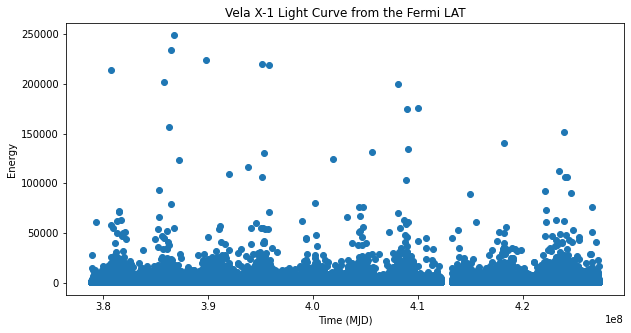

Min Time: 378869360.8744677
Max Time: 427240400.54758215


In [30]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

filepath = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/L241111092405F357373F82_PH02.fits'
# Load the file again to access specific columns
with fits.open(filepath) as hdul:
    data = hdul[1].data # Assuming light curve data is in the first extension

    time = data['TIME']
    energy = data['ENERGY']
    # error = data['ERROR'] if 'ERROR' in data.columns.names else None

    # Plotting the light curve
    plt.figure(figsize=(10, 5))
    #plt.errorbar(time, energy, fmt='.k', ecolor='red', capsize=2, label='Vela X-1 Light Curve')
    plt.scatter(time,energy)
    plt.xlabel('Time (MJD)')
    plt.ylabel('Energy')
    plt.title('Vela X-1 Light Curve from the Fermi LAT')
    #plt.legend()
    #plt.xlim([56000,56500])
    plt.show()

    print(f"Min Time: {np.min(time)}")
    print(f"Max Time: {np.max(time)}")

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import warnings

def load_multiple_fits_data(folder_path, file_list):
    """
    Load data from multiple FITS files and concatenate the time and energy data.
    
    Parameters:
    - folder_path (str): Path to the folder containing FITS files.
    - file_list (list): List of FITS filenames to process.

    Returns:
    - combined_time (np.ndarray): Concatenated array of times.
    - combined_energy (np.ndarray): Concatenated array of energy values.
    """
    # Initialize combined_time and combined_energy as empty numpy arrays
    combined_time = np.array([])
    combined_energy = np.array([])
    combined_ra = np.array([])
    combined_dec = np.array([])
    combined_ph = np.array([])
    combined_gti_start = np.array([])
    combined_gti_stop = np.array([])

    for filename in file_list:
        filepath = os.path.join(folder_path, filename)
        try:
            with fits.open(filepath) as hdul:
                data = hdul[1].data  # Assuming light curve data is in the first extension
                ext1 = hdul[2].data
                print(data.__dict__)
                print(ext1.__dict__)
                time = data['TIME']
                energy = data['ENERGY']
                ra = data['RA']
                dec = data['DEC']
                gti_start = ext1['START']
                gti_stop = ext1['STOP']
                print(f"File: {filename} - Time entries: {len(time)}")

                # Concatenate the data from each file
                combined_time = np.concatenate((combined_time, time))
                combined_energy = np.concatenate((combined_energy, energy))
                combined_ra = np.concatenate((combined_ra, ra))
                combined_dec = np.concatenate((combined_dec, dec))
                combined_gti_start = np.concatenate((combined_gti_start, gti_start))
                combined_gti_stop = np.concatenate((combined_gti_stop, gti_stop))
                print(f"Combined time length: {len(combined_time)}")
        except Exception as e:
            warnings.warn(f"Could not load file {filepath}: {e}")
            continue

    return combined_time, combined_energy, combined_ra, combined_dec, combined_gti_start, combined_gti_stop

In [58]:
folder_path = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/'
#file_list = ['L241111092405F357373F82_PH00.fits','L241111092405F357373F82_PH01.fits','L241111092405F357373F82_PH02.fits','L241111092405F357373F82_PH03.fits','L241111092405F357373F82_PH04.fits','L241111092405F357373F82_PH05.fits','L241111092405F357373F82_PH06.fits']
file_list = ['L241111092405F357373F82_PH00.fits'] #,'L241111092405F357373F82_PH01.fits']

#folder_path = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/crabpulsar/'
#file_list = ['L241114150729F357373F38_PH00.fits','L241114150729F357373F38_PH01.fits','L241114150729F357373F38_PH02.fits']#

#folder_path = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velapulsar/'
#file_list = ['L241115062446F357373F53_PH00.fits', 'L241115062446F357373F53_PH01.fits','L241115062446F357373F53_PH02.fits']

combined_time, combined_energy, combined_ra, combined_dec, combined_ph, combined_gti_start, combined_gti_stop = load_multiple_fits_data(folder_path, file_list)
#print(combined_time)

{'_nfields': 23, '_converted': {}, '_heapoffset': 52411282, '_heapsize': 0, '_gap': 0, '_uint': True, '_col_weakrefs': <_weakrefset.WeakSet object at 0x7fb9e4eb6fd0>, '_coldefs': ColDefs(
    name = 'ENERGY'; format = 'E'; unit = 'MeV'
    name = 'RA'; format = 'E'; unit = 'deg'
    name = 'DEC'; format = 'E'; unit = 'deg'
    name = 'L'; format = 'E'; unit = 'deg'
    name = 'B'; format = 'E'; unit = 'deg'
    name = 'THETA'; format = 'E'; unit = 'deg'
    name = 'PHI'; format = 'E'; unit = 'deg'
    name = 'ZENITH_ANGLE'; format = 'E'; unit = 'deg'
    name = 'EARTH_AZIMUTH_ANGLE'; format = 'E'; unit = 'deg'
    name = 'TIME'; format = 'D'; unit = 's'
    name = 'EVENT_ID'; format = 'J'
    name = 'RUN_ID'; format = 'J'
    name = 'RECON_VERSION'; format = 'I'
    name = 'CALIB_VERSION'; format = '3I'
    name = 'EVENT_CLASS'; format = '32X'
    name = 'EVENT_TYPE'; format = '32X'
    name = 'CONVERSION_TYPE'; format = 'I'
    name = 'LIVETIME'; format = 'D'; unit = 's'
    name = 'D

In [44]:
period = 89.33e-3
1/period

11.194447554013209

## Plotting Binned Timeseries and Pulse Profiles

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time, TimeDelta
import os
import warnings

def convert_mission_time_to_unix(seconds_since_mission_start):
    """
    Convert Fermi MET (seconds since January 1, 2001) to Unix timestamp format.
    """
    # Define Fermi mission start time in MJD
    mjdref = 51910.00074287037037037  # Fermi mission reference in MJD
    # Convert Fermi mission reference to Unix time
    mission_start_unix = Time(mjdref, format='mjd', scale='tt').unix
    # Add seconds since mission start to mission_start_unix to get the Unix timestamps
    unix_timestamps = mission_start_unix + seconds_since_mission_start
    return unix_timestamps

def convert_to_unix_timestamp(seconds_since_mission_start, obs_start_seconds, obs_start_iso):
    """
    Convert an array of times in seconds since mission start into Unix timestamp format.
    """
    # Define the start time of the observation in ISO format
    observation_start = Time(obs_start_iso, format='isot', scale='utc')
    # Calculate the mission start time by subtracting the observation start offset in seconds
    mission_start = observation_start - TimeDelta(obs_start_seconds, format='sec')
    # Add seconds since mission start to calculate the final times
    times = mission_start + TimeDelta(seconds_since_mission_start, format='sec')
    # Extract Unix timestamps from the resulting times
    unix_timestamps = times.unix
    return unix_timestamps

def convert_times(seconds_since_mission_start, obs_start_seconds, obs_start_iso):
    """
    Convert an array of times in seconds since mission start into MJD and Unix ISO formats.
    """
    observation_start = Time(obs_start_iso, format='isot', scale='utc')
    mission_start = observation_start - TimeDelta(obs_start_seconds, format='sec')
    times = mission_start + TimeDelta(seconds_since_mission_start, format='sec')
    mjd_times = times.mjd
    unix_iso_times = times.isot
    return mjd_times, unix_iso_times

def plot_binned_light_curve(mjd_times, ratedata, title_prefix, start_time=None, end_time=None, bin_size_seconds=60):
    """
    Plot a binned light curve over a specified time range.

    Parameters:
    - mjd_times (np.ndarray): Array of times in MJD.
    - ratedata (np.ndarray): Array of rate data.
    - title_prefix (str): Title prefix for the plot.
    - start_time (float, optional): Start of the time range for plotting in MJD. Defaults to minimum MJD time.
    - end_time (float, optional): End of the time range for plotting in MJD. Defaults to maximum MJD time.
    - bin_size_seconds (float, optional): Desired bin size in seconds. Default is 3600 seconds (1 hour).
    """
    # Validate and set default time range if needed
    if start_time is None or start_time < np.min(mjd_times) or start_time > np.max(mjd_times):
        start_time = np.min(mjd_times)
        warnings.warn("Invalid or missing start time provided. Using minimum available MJD time.")
    
    if end_time is None or end_time > np.max(mjd_times) or end_time < np.min(mjd_times):
        end_time = np.max(mjd_times)
        warnings.warn("Invalid or missing end time provided. Using maximum available MJD time.")

    # Set bin size based on the specified range
    #bin_size = (end_time - start_time) / 1000
    #num_bins = int((end_time - start_time) / bin_size)

    #bin_size_days = bin_size_seconds / (24 * 3600)  # Convert seconds to days
    num_bins = int((end_time - start_time) / bin_size_seconds)

    # Bin the data within the specified range
    event_counts, bin_edges = np.histogram(mjd_times, bins=num_bins, range=(start_time, end_time))
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2

    # Calculate the y-axis scale based on the actual data in the selected range
    y_max = np.max(event_counts) * 1.1

    # Time range in the title
    range_seconds = end_time - start_time
    range_days = range_seconds/(24*3600)
    range_hours = range_seconds/3600
    range_title = f"{range_days:.2f} days" if range_days >= 1 else f"{range_hours:.1f} h"

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(bin_centers, event_counts, drawstyle='steps-mid', color='darkblue')
    plt.xlabel("Time (UNIX)")
    plt.ylabel("Event Count")
    plt.title(f"{title_prefix} Binned Light Curve ({range_title} - bin_size: {bin_size_seconds} s)")
    plt.ylim(0, y_max)
    #plt.xlim(1.3215e9,1.3295e9)
    plt.grid()
    plt.show()

[1.26230405e+09 1.26230423e+09 1.26230425e+09 ... 1.30878560e+09
 1.30878564e+09 1.30878572e+09]


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/ipykernel_launcher.py:60: UserWarning: Invalid or missing start time provided. Using minimum available MJD time.
/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/ipykernel_launcher.py:64: UserWarning: Invalid or missing end time provided. Using maximum available MJD time.


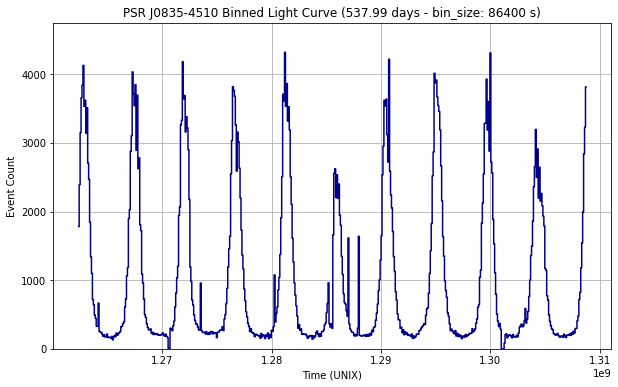

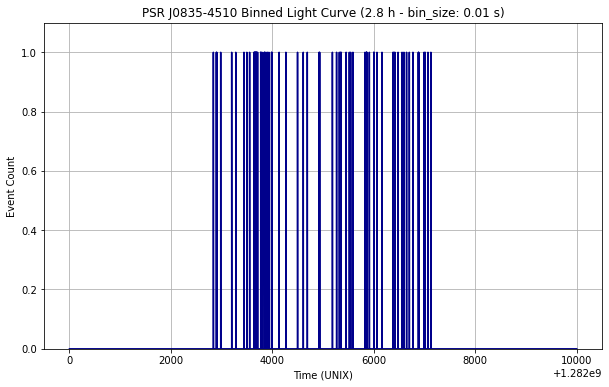

In [60]:
target_name = "Vel X-1"
target_name = 'PSR J0835-4510'
start_obs = "2024-05-08T11:33:19.9999"
start_obs_mission = 736860804.0

#mjd_times, unix_iso_times = convert_times(combined_time, start_obs_mission, start_obs)
unix_timestamps = convert_mission_time_to_unix(combined_time)

print(unix_timestamps)
plot_binned_light_curve(unix_timestamps, combined_energy, target_name, bin_size_seconds = 24*3600)
plot_binned_light_curve(unix_timestamps, combined_energy, target_name, start_time = (1.282e9), end_time= (1.28201e9), bin_size_seconds =0.01)

774520.4447999999
1.2911215019743274e-06
[9.73171278e+08 9.73171288e+08 9.73171298e+08 ... 9.73226463e+08
 9.73226483e+08 9.73226503e+08]


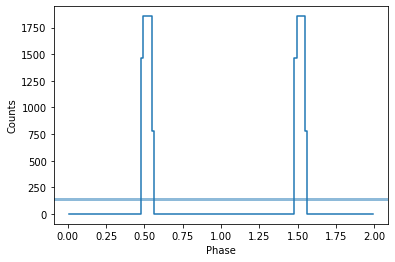

In [ ]:
from stingray.pulse.pulsar import fold_events
from stingray.pulse.search import plot_profile
nbin = 73
period = 8.964357 * 3600 * 24 # orbital period in seconds
print(period)
print(1/period)
print(unix_timestamps)
np.array([[unix_timestamps[0], unix_timestamps[-1]]])
ph, profile, profile_err = fold_events(unix_timestamps, 1/period, nbin=nbin)
_ = plot_profile(ph, profile)

52.84965330627431


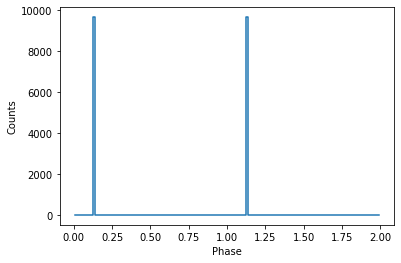

In [173]:
nbin = 73
period = 1/2.19e-7
print(period/(3600*24))
ph, profile, profile_err = fold_events(unix_timestamps, 1/period, nbin=nbin)
_ = plot_profile(ph, profile)

283


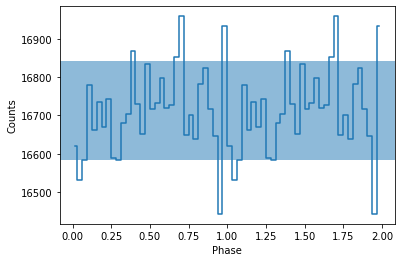

In [36]:
nbin = 32
period = 283
print(period)
ph, profile, profile_err = fold_events(unix_timestamps, 1/period, nbin=nbin)
_ = plot_profile(ph, profile)

In [49]:
import pylab as pl
import matplotlib as mpl
import astropy.units as u
from astroquery.simbad import Simbad
from astropy.coordinates import get_icrs_coordinates, SkyCoord

vela_coords = get_icrs_coordinates('PSR J0835-4510')
velra0 = vela_coords.ra.value
veldec0 = vela_coords.dec.value
print(f"ICRS: RA {velra0}, DEC {veldec0}")


# Convert velra0, veldec0 to Galactic coordinates
vel_coords = SkyCoord(velra0 * u.deg, veldec0 * u.deg, frame='icrs')
l_vel = vel_coords.galactic.l.value
b_vel = vel_coords.galactic.b.value
print(f"ICRS: Gal_L {l_vel}, Gal_B {b_vel}")


target_name2 = 'PSR J0835-4510'
target_name = "Vela X-1"

def make_counts_map(target_name,target_name2, ra, dec, en):
    simbad = Simbad()
    simbad_data = simbad.query_object(target_name)

    print("Coordinates from Simbad:", simbad_data)
    ra0, dec0 = simbad_data['RA'][0], simbad_data['DEC'][0]
    print(f"Simbad: RA {ra0}, DEC {dec0}")

    mask = en > 1000
    c = SkyCoord(ra[mask]*u.deg, dec[mask]*u.deg, frame = 'icrs')
    c0 = SkyCoord(ra0, dec0, unit=(u.deg, u.deg))

    

    gal = c.galactic 
    gal_b = gal.b.value
    gal_l = gal.l.value
    b0 = c0.galactic.b.value
    l0 = c0.galactic.l.value

    print(f"Simbad: Gal_L {l0}, Gal_B {b0}")

    l_bins = np.linspace(l0 - 10, l0 + 10, 41)
    b_bins = np.linspace(b0 - 10, b0 + 10, 41)

    pl.figure(1); pl.clf()
    pl.hist2d(gal_l, gal_b, bins = [l_bins, b_bins], norm = mpl.colors.LogNorm(), vmin=2e2, vmax=1e4)
    # Plot markers for velra0/veldec0 and l0/b0
    plt.scatter(l_vel, b_vel, color='blue', label=f'{target_name2}')
    plt.scatter(l0, b0, color='red', label=f'{target_name}')
    plt.xlabel('Galactic Longitude (l)')
    plt.ylabel('Galactic Latitude (b)')
    plt.legend()
    plt.title('Counts Map in Galactic Coordinates')
    plt.show()

    

ICRS: RA 128.836063542, DEC -45.176431806
ICRS: Gal_L 263.5519707057637, Gal_B -2.787255872163032


Coordinates from Simbad:  MAIN_ID        RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                     
--------- ------------- ------------- ... ------------------- ----------------
V* GP Vel 09 02 06.8608 -40 33 16.899 ... 2020yCat.1350....0G                1
Simbad: RA 09 02 06.8608, DEC -40 33 16.899
Simbad: Gal_L 315.20360403459983, Gal_B -76.20693811157479


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/ipykernel_launcher.py:49: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.


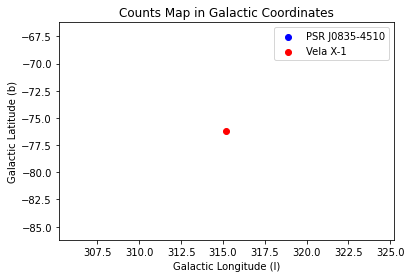

In [50]:
make_counts_map(target_name, target_name2, combined_ra, combined_dec, combined_energy)

In [46]:
def plot_pulse_profile(en, ph, ti):
    mask = en > 1000
    pl.figure(5); pl.clf()
    pl.hist(ph[mask],bins=np.linspace(0,1,21),hisstype='step')
    
    


In [ ]:
plot_pulse_profile(combined_energy,combined_phase,combined_time)

## XMM Newton Data

In [5]:
from astroquery.heasarc import Heasarc
from astroquery.simbad import Simbad
heasarc = Heasarc()
heasarc_tables = heasarc.query_mission_list()
heasarc_tables

import requests
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

# Replace `data_url` with the actual URL from your query
data_url = "https://heasarc.gsfc.nasa.gov/..."  # Example URL from response.url
response = requests.get(data_url)

# Save the file to disk
with open("vela_x1_data.vot", "wb") as file:
    file.write(response.content)

heasarc = Heasarc()

target_name = "Vela X-1"
mission = 'xmmstack'

simbad = Simbad()
simbad_data = simbad.query_object(target_name)

print("Coordinates from Simbad:", simbad_data)

ra, dec = simbad_data['RA'][0], simbad_data['DEC'][0]
coords = SkyCoord(ra, dec, unit=(u.hourangle, u.deg),frame= 'icrs' )

# Get the query payload to see what the request looks like
payload = heasarc.query_region(coords, mission=mission, radius='3 degree', get_query_payload=True)
print("Payload:", payload)

response = heasarc.query_object_async(target_name, mission=mission, displaymode='URL')
print("Data URL:", response.url) 

responseurl = requests.get(response.url)

# Save the file to disk
with open("vela_x1_data.vot", "wb") as file:
    file.write(responseurl.content)

#table = heasarc.query_region(coords, mission=mission, radius='1 degree', get_query_payload=False, displaymode='VOTableDisplay')
#table[:3].pprint(max_width=-1)


Coordinates from Simbad:  MAIN_ID        RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                     
--------- ------------- ------------- ... ------------------- ----------------
V* GP Vel 09 02 06.8608 -40 33 16.899 ... 2020yCat.1350....0G                1
Payload: {'tablehead': 'name=BATCHRETRIEVALCATALOG_2.0 xmmstack', 'Entry': '135.5285948880,-40.5546998430', 'Action': 'Query', 'displaymode': 'FitsDisplay', 'resultsmax': '10', 'Coordinates': 'Equatorial: R.A. Dec', 'Radius': '180.0 arcmin'}
Data URL: https://heasarc.gsfc.nasa.gov/db-perl/W3Browse/w3query.pl?tablehead=name%3DBATCHRETRIEVALCATALOG_2.0+xmmstack&Entry=Vela+X-1&Action=Query&displaymode=URL&resultsmax=10&Coordinates=Equatorial%3A+R.A.+Dec


#### Downloading and unpacking the data

- Klick on the link created above
- Select Rows and klick on 'Obs' under 'Related Links'
- Select All Rows and wanted Data Products (Important one: XMM Pipeline Products)
- Klick 'Preview and Retrieve'
- Select FITS File to download: XMM Pipeline Products (PPS)
#
- scp the downloaded file to woody: (in woody software directory) scp .\w3browse-229101.tar capn107h@csnhr.nhr.fau.de:/home/hpc/capn/capn107h/software
- if neccessary move to corresponding data/photon_lightcurves folder
- unpack wanted folder: -xvf w3browse-229101.tar
- Look for Timing data: capn107h@woodycap5:~/software/psr/data/photon_lightcurves/velax-1/0111030101/PPS$ ls \*SRCTSR\*
- Copy filepath of wanted file for usage below
#
#
Wat is mit der Zeit?

XTENSION = BINTABLE / binary table extension
BITPIX = 8 / 8-bit bytes
NAXIS = 2 / 2-dimensional binary table
NAXIS1 = 28 / width of table in bytes
NAXIS2 = 21 / number of rows in table
PCOUNT = 0 / size of special data area
GCOUNT = 1 / one data group (required keyword)
TFIELDS = 6 / number of fields in each row
TTYPE1 = TIME / Time of the center of each frame
TFORM1 = D / data format of field: 8-byte DOUBLE
TUNIT1 = s / physical unit of field
TTYPE2 = RATE / Source Count Rate
TFORM2 = E / data format of field: 4-byte REAL
TUNIT2 = count/s / physical unit of field
TTYPE3 = ERROR / Error in Source light curve
TFORM3 = E / data format of field: 4-byte REAL
TUNIT3 = count/s / physical unit of field
TTYPE4 = FRACEXP / effective time /
 real time
TFORM4 = E / data format of field: 4-byte REAL
TUNIT4 = fraction / physical unit of field
TTYPE5 = BACKV / Bkg rate normalized to src area
TFORM5 = E / data format of field: 4-byte REAL
TUNIT5 = count/s / physical unit of field
TTYPE6 = BACKE / Err

<ErrorbarContainer object of 3 artists>

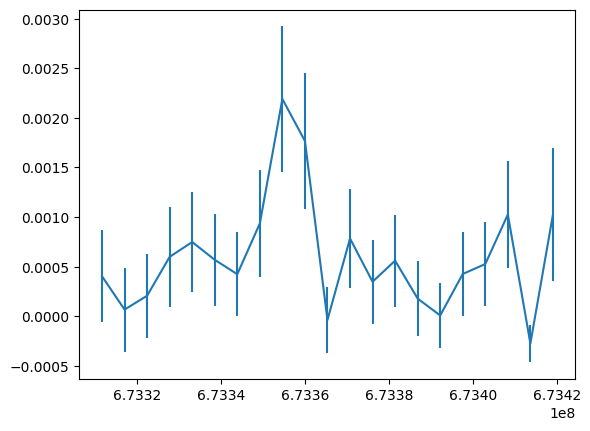

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time, TimeDelta
import os
import warnings

# P0841890201M1S001SRCTSR8008.FTZ 
# P0841890201M1X000SRCTSR8008.FTZ
# P0841890201M2S002SRCTSR8008.FTZ 
#filepath = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/0111030101/ODF/0165_0111030101_M2U00310TIE.FIT'
filepath = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/0111030101/PPS/P0111030101M1U002SRCTSR8001.FTZ'
filepath = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/0841890201/PPS/P0841890201M1S001SRCTSR8008.FTZ'

## ODF: Raw Files (Much too raw!)
## PPS: After Pipeline (Mmhhh!)
## M1: EPIC MOS-1
## SRCTSR: EPIC Source Timeseries 
## hdul[0]: header as always
## hdul[1]: timeseries data (time, rate, error)
## hdul[2]: gti data (start, stop)

from astropy.io import fits

with fits.open(filepath) as hdul:
                for key, value, comment in hdul[1].header.cards:
        # Print the header with line breaks after '/'
                    if comment:
                        comment = comment.replace('/', '/\n')  # Add line breaks after each '/'
                    print(f"{key} = {value} / {comment}")
                data = hdul[1].data  # Assuming light curve data is in the first extension
                print(data.__dict__)
                print(data['TIME'])
                print(data['RATE'])


                time = data['TIME']
                rate = data['RATE']
                err  =data['ERROR']

                print(len(time))
                print(np.min(time))
                print(np.max(time))


plt.errorbar(time,rate,err)

Unix Times: [9.73171278e+08 9.83609200e+08 8.95954879e+08]
MJDs: [51850.55646035 51971.36574074 50956.84813542]


<ErrorbarContainer object of 3 artists>

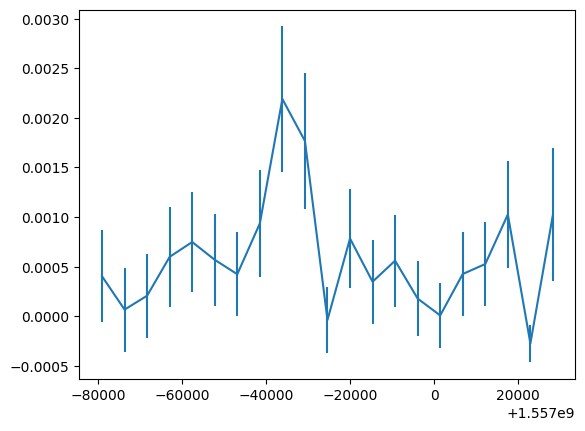

In [16]:
import numpy as np
from datetime import datetime


def mission_times_to_unix_and_mjd(mission_seconds_array):
    """
    Converts an array of mission seconds to Unix time and MJD.

    Args:
    - mission_seconds_array (array-like): Array of mission seconds since 1998-01-01 00:00:00.

    Returns:
    - unix_times (np.ndarray): Array of Unix timestamps.
    - mjds (np.ndarray): Array of Modified Julian Dates (MJD).
    """
    # Mission start timestamp: 1998-01-01 00:00:00 UTC
    mission_start_unix = int(datetime(1998, 1, 1, 0, 0, 0).timestamp())
    
    # Ensure input is a numpy array for vectorized operations
    mission_seconds_array = np.asarray(mission_seconds_array, dtype=np.float64)
    
    # Calculate Unix timestamps
    unix_times = mission_start_unix + mission_seconds_array
    
    # Convert Unix timestamps to MJD
    mjds = unix_times / 86400 + 40587
    
    return unix_times, mjds

# Example usage
mission_seconds_array = [89562078.174256, 100000000.0, 12345678.9]
unix_times, mjds = mission_times_to_unix_and_mjd(mission_seconds_array)

print("Unix Times:", unix_times)
print("MJDs:", mjds)


xmm_unix_times, xmm_mjd_times = mission_times_to_unix_and_mjd(time)
#plt.errorbar(xmm_unix_times,rate,err)
plt.errorbar(xmm_unix_times,rate,err)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import warnings

def load_multiple_fits_data_xmm(folder_path, file_list):
    """
    Load data from multiple FITS files and concatenate the time and energy data.
    
    Parameters:
    - folder_path (str): Path to the folder containing FITS files.
    - file_list (list): List of FITS filenames to process.

    Returns:
    - combined_time (np.ndarray): Concatenated array of times.
    - combined_energy (np.ndarray): Concatenated array of energy values.
    """
    # Initialize combined_time and combined_energy as empty numpy arrays
    combined_time = np.array([])
    combined_energy = np.array([])
    combined_error = np.array([])

    for filename in file_list:
        filepath = os.path.join(folder_path, filename)
        try:
            with fits.open(filepath) as hdul:
                data = hdul[1].data  # Assuming light curve data is in the first extension
                print(data.__dict__)
                time = data['TIME']
                energy = data['RATE']
                error = data['ERROR']
                print(f"File: {filename} - Time entries: {len(time)} - Min Time: {np.min(time)} - Max Time: {np.max(time)}")
                
                # Concatenate the data from each file
                combined_time = np.concatenate((combined_time, time))
                combined_energy = np.concatenate((combined_energy, energy))
                combined_error = np.concatenate((combined_error, error))
                print(f"Combined time length: {len(combined_time)}")
                print(f"rate: {energy}")
        except Exception as e:
            warnings.warn(f"Could not load file {filepath}: {e}")
            continue

    return combined_time, combined_energy, combined_error

{'_nfields': 6, '_converted': {}, '_heapoffset': 1316, '_heapsize': 0, '_gap': 0, '_uint': True, '_col_weakrefs': {<weakref at 0x7f6a6e9339f0; to 'Column' at 0x7f6a6e6f51f0>, <weakref at 0x7f6a6e933590; to 'Column' at 0x7f6a6e6f55e0>, <weakref at 0x7f6a6e8dfe50; to 'Column' at 0x7f6a6e74e0a0>, <weakref at 0x7f6a6e933e50; to 'Column' at 0x7f6a6e6f53a0>, <weakref at 0x7f6a6e933c70; to 'Column' at 0x7f6a6e6f57f0>, <weakref at 0x7f6a6e933130; to 'Column' at 0x7f6a6e6f56d0>}, '_coldefs': ColDefs(
    name = 'TIME'; format = 'D'; unit = 's'
    name = 'RATE'; format = 'E'; unit = 'count/s'
    name = 'ERROR'; format = 'E'; unit = 'count/s'
    name = 'FRACEXP'; format = 'E'; unit = 'fraction'
    name = 'BACKV'; format = 'E'; unit = 'count/s'
    name = 'BACKE'; format = 'E'; unit = 'count/s'
), '_load_variable_length_data': True, '_character_as_bytes': False}
File: P0841890201M1S001SRCTSR8003.FTZ - Time entries: 47 - Min Time: 673310200.27805 - Max Time: 673419680.27805
Combined time length

<ErrorbarContainer object of 3 artists>

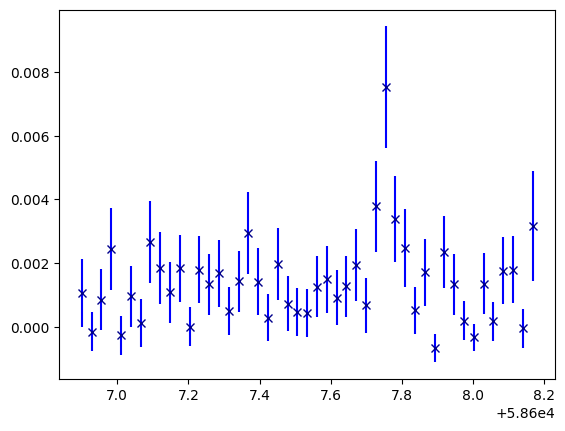

In [26]:
folder_path = '/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/0841890201/PPS/'
file_list = ['P0841890201M1S001SRCTSR8003.FTZ'] #,'P0111030101M1U002SRCTSR8002.FTZ','P0111030101M1U002SRCTSR8003.FTZ']

# Are those files even from different times? And if so, where did it go wrong when combining them?

combined_time, combined_rates, combined_error = load_multiple_fits_data_xmm(folder_path, file_list)
unix_timestamps, xmm_mjd_times = mission_times_to_unix_and_mjd(combined_time)
print(xmm_mjd_times)
print(combined_rates)
plt.errorbar(xmm_mjd_times,combined_rates,combined_error,c="darkblue",marker='x',ls=" ",ecolor="blue")
#plt.xlim([0.8+5.185e4,0.81+5.185e4])
#plt.scatter(xmm_mjd_times,combined_rates, c="k")
#print(unix_timestamps)

In [13]:
from stingray.events import EventList
from stingray import Lightcurve

period = 283

# use the light curve above to simulate an event list for this pulsar.
lc = Lightcurve(unix_timestamps,combined_rates,combined_error, input_counts=False)
events = EventList()
events.simulate_times(lc)
print(len(events.time))
print(events.time)

239431
[9.73171273e+08 9.73171273e+08 9.73171274e+08 ... 9.73226512e+08
 9.73226512e+08 9.73226513e+08]


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/stingray/pulse/search.py:332: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = plt.subplot()


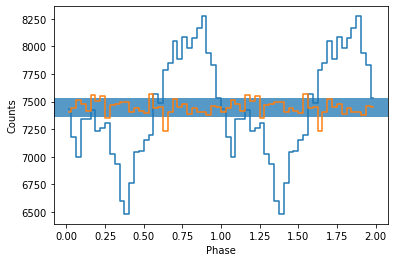

In [29]:

from stingray.pulse.pulsar import fold_events
from stingray.pulse.search import plot_profile
nbin = 32

ph, profile, profile_err = fold_events(events.time, 1/period, nbin=nbin)
_ = plot_profile(ph, profile)

ph, profile, profile_err = fold_events(events.time, 1/1.1, nbin=nbin)
_ = plot_profile(ph, profile)

In [73]:
import h5py

gti_file = "/home/hpc/capn/capn107h/software/psr/data/photon_lightcurves/velax-1/L241111092405F357373F82_PH0_fermi_xray_lightcurve_gtilist.hdf5"

with h5py.File(gti_file, 'r') as gti_h5:
    print("Top-level keys:", list(gti_h5.keys()))  # Lists the datasets/groups at the top level
    for key in gti_h5.keys():
        print(f"Contents of {key}:")
        print(gti_h5.__astropy_table__)
        print(gti_h5['gti_start'])

Top-level keys: ['__astropy_table__', '__astropy_table__.__table_column_meta__']
Contents of __astropy_table__:


AttributeError: 'File' object has no attribute '__astropy_table__'

In [ ]:
from astropy.io.misc.hdf5 import read_table_hdf5
# Change this in SDcript
table = read_table_hdf5(gti_file)

In [76]:
print(table['gti_start'])

    gti_start     
------------------
       283996802.0
284001369.90454954
284007152.90816027
 284012413.9106147
284018415.91408795
284024143.90985465
284029872.90819067
284035601.90655476
 284041330.9047483
284045163.90979326
               ...
 378807469.6338815
 378813438.6395519
  378819391.630522
378825074.63252467
 378830661.6287988
 378836383.6307954
378842106.63227564
378847828.63233477
 378853550.6306735
 378859272.6323172
378863193.63191605
Length = 17285 rows


# Creating dummy signal for GTI testing

In [1]:
import numpy as np
import h5py
from astropy.table import Table

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 1000  # Total duration of the dataset in seconds
signal_frequency = 0.1  # Frequency of the periodic signal in Hz
sampling_rate = 1000  # Number of events per second
noise_level = 0.5  # Noise level for the event times
missing_period = 10  # Period of the missing data in seconds
missing_duration = 5  # Duration of the missing parts in seconds

# Parameters for GTI
gti_filename = "gti.hdf5"
data_filename = "dummy_data.hdf5"

# Generate event times with a periodic signal and noise
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)
signal = np.sin(2 * np.pi * signal_frequency * (time - start_time)) > 0  # Binary signal
event_times = time[signal] + np.random.uniform(-noise_level, noise_level, size=sum(signal))

# Create gaps in the data to simulate missing parts
missing_intervals = [
    (start_time + start, start_time + start + missing_duration)
    for start in np.arange(0, total_time, missing_period)
]
valid_mask = np.ones_like(event_times, dtype=bool)

for start, stop in missing_intervals:
    valid_mask &= ~((event_times >= start) & (event_times < stop))

valid_event_times = event_times[valid_mask]
event_energies = np.random.uniform(1, 10, size=len(valid_event_times))  # Random energies

# Save the event data to HDF5
with h5py.File(data_filename, "w") as f:
    f.create_dataset("time", data=valid_event_times)
    f.create_dataset("energy", data=event_energies)

print(f"Data saved to {data_filename}")

# Generate GTI data specifying valid intervals
gti_starts = []
gti_stops = []

for start, stop in missing_intervals:
    if gti_starts:
        gti_starts.append(gti_stops[-1])
    else:
        gti_starts.append(start_time)
    gti_stops.append(start)

gti_starts.append(gti_stops[-1])
gti_stops.append(start_time + total_time)

gti_starts = np.array(gti_starts[1:])  # Remove leading initial interval
gti_stops = np.array(gti_stops[:-1])   # Remove trailing total_time interval

gti_table = Table({"gti_start": gti_starts, "gti_stop": gti_stops})
gti_table.write(gti_filename, format="hdf5", overwrite=True)

print(f"GTI saved to {gti_filename}")


Data saved to dummy_data.hdf5
GTI saved to gti.hdf5


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astropy/io/misc/hdf5.py:284: UserWarning: table path was not set via the path= argument; using default path __astropy_table__
  "using default path {}".format(path))


In [3]:
# Generate GTI data specifying valid intervals
gti_starts = []
gti_stops = []

# Create valid intervals between missing periods
prev_stop = start_time  # Start of the first valid interval
for start, stop in missing_intervals:
    gti_starts.append(prev_stop)  # Start of the valid interval
    gti_stops.append(start)       # End of the valid interval
    prev_stop = stop              # Update for the next valid interval

# Add the final valid interval after the last missing segment
gti_starts.append(prev_stop)
gti_stops.append(start_time + total_time)

# Convert to arrays
gti_starts = np.array(gti_starts)
gti_stops = np.array(gti_stops)

# Save GTI to file
gti_table = Table({"gti_start": gti_starts, "gti_stop": gti_stops})
print(gti_table)
gti_table.write(gti_filename, format="hdf5", overwrite=True)

print(f"GTI saved to {gti_filename}")

gti_start   gti_stop 
---------- ----------
1262304000 1262304000
1262304005 1262304010
1262304015 1262304020
1262304025 1262304030
1262304035 1262304040
1262304045 1262304050
1262304055 1262304060
1262304065 1262304070
1262304075 1262304080
1262304085 1262304090
       ...        ...
1262304895 1262304900
1262304905 1262304910
1262304915 1262304920
1262304925 1262304930
1262304935 1262304940
1262304945 1262304950
1262304955 1262304960
1262304965 1262304970
1262304975 1262304980
1262304985 1262304990
1262304995 1262305000
Length = 101 rows
GTI saved to gti.hdf5


/home/hpc/capn/capn107h/software/km3astrovenv/lib64/python3.6/site-packages/astropy/io/misc/hdf5.py:284: UserWarning: table path was not set via the path= argument; using default path __astropy_table__
  "using default path {}".format(path))


In [ ]:
import numpy as np
from astropy.table import Table
from astropy.io import fits

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 1000  # Total duration of the dataset in seconds
signal_frequency = 0.1  # Frequency of the periodic signal in Hz
sampling_rate = 1000  # Number of events per second
noise_level = 0.5  # Noise level for the event times
missing_period = 10  # Period of the missing data in seconds
missing_duration = 5  # Duration of the missing parts in seconds

# Parameters for GTI
gti_filename = "gti.hdf5"
data_filename = "dummy_data.hdf5"

# Generate event times with a periodic signal and noise
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)
signal = np.sin(2 * np.pi * signal_frequency * (time - start_time)) > 0  # Binary signal
event_times = time[signal] + np.random.uniform(-noise_level, noise_level, size=sum(signal))

# Create gaps in the data to simulate missing parts
missing_intervals = [
    (start_time + start, start_time + start + missing_duration)
    for start in np.arange(0, total_time, missing_period)
]
valid_mask = np.ones_like(event_times, dtype=bool)

for start, stop in missing_intervals:
    valid_mask &= ~((event_times >= start) & (event_times < stop))

valid_event_times = event_times[valid_mask]
event_energies = np.random.uniform(1, 10, size=len(valid_event_times))  # Random energies

ras = np.random.uniform(0, 360, len(valid_event_times))  # Random RA values
decs = np.random.uniform(-90, 90, len(valid_event_times))  # Random Dec values

# Generate dummy GTI data
gti_starts = np.arange(start_time, end_time, 50)
gti_stops = gti_starts + 40

# Create event list table
event_table = Table(
    [times, energies, ras, decs],
    names=("time", "energy", "ra", "dec")
)

# Create GTI table
gti_table = Table(
    [gti_starts, gti_stops],
    names=("gti_start", "gti_stop")
)

# Write to HDF5 file
output_file = "dummy_eventlist.hdf5"
event_table.write(output_file, format="hdf5", overwrite=True, serialize_meta=True)

gti_output_file = "dummy_gtilist.hdf5"
gti_table.write(gti_output_file, format="hdf5", overwrite=True, serialize_meta=True)

print(f"Dummy event list saved to {output_file}")
print(f"Dummy GTI list saved to {gti_output_file}")


Dummy event list saved to dummy_eventlist.hdf5
Dummy GTI list saved to dummy_gtilist.hdf5


In [7]:
import numpy as np
from astropy.table import Table
import os

# File names
data_filename = "dummy_eventlist.hdf5"
gti_filename = "dummy_gtilist.hdf5"

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 10000  # Total duration of the dataset in seconds
signal_frequency = 0.1  # Frequency of the periodic signal in Hz
sampling_rate = 1000  # Number of events per second
noise_level = 0.2  # Noise level for the event times
missing_period = 30  # Period of the missing data in seconds
missing_duration = 5  # Duration of the missing parts in seconds

# Generate event times with a periodic signal and noise
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)
signal = np.sin(2 * np.pi * signal_frequency * (time - start_time)) > 0  # Binary signal
event_times = time[signal] + np.random.uniform(-noise_level, noise_level, size=sum(signal))

# Create gaps in the data to simulate missing parts
missing_intervals = [
    (start_time + start, start_time + start + missing_duration)
    for start in np.arange(0, total_time, missing_period)
]
valid_mask = np.ones_like(event_times, dtype=bool)

for start, stop in missing_intervals:
    valid_mask &= ~((event_times >= start) & (event_times < stop))

valid_event_times = event_times[valid_mask]
event_energies = np.random.uniform(1, 10, size=len(valid_event_times))  # Random energies
event_ras = np.random.uniform(0, 360, size=len(valid_event_times))  # Random RA values
event_decs = np.random.uniform(-90, 90, size=len(valid_event_times))  # Random Dec values

# Create GTIs based on missing intervals
gti_starts = [start_time]
gti_stops = []

for start, stop in missing_intervals:
    gti_stops.append(start)  # Current gap's start marks the GTI's end
    gti_starts.append(stop)  # Current gap's end marks the next GTI's start

gti_starts = np.array(gti_starts[:-1])  # Remove the last unused start
gti_stops = np.array(gti_stops)  # Stop just before the first missing interval

# Save the event list and GTIs
event_table = Table(
    [valid_event_times, event_energies, event_ras, event_decs],
    names=("time", "energy", "ra", "dec")
)
gti_table = Table(
    [gti_starts, gti_stops],
    names=("gti_start", "gti_stop")
)

# Save files
event_table.write(data_filename, format="hdf5", overwrite=True, serialize_meta=True)
gti_table.write(gti_filename, format="hdf5", overwrite=True, serialize_meta=True)

print(f"Event list saved to {data_filename}")
print(f"GTI list saved to {gti_filename}")



Event list saved to dummy_eventlist.hdf5
GTI list saved to dummy_gtilist.hdf5


In [ ]:
import numpy as np
from astropy.table import Table
import os

# File names
data_filename = "multi_signal_eventlist.hdf5"
gti_filename = "primary_signal_gtilist.hdf5"

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 100000  # Total duration of the dataset in seconds
signal_frequency1 = 0.001  # Frequency of the primary signal in Hz
signal_frequency2 = 0.003  # Frequency of the secondary signal in Hz
sampling_rate = 100  # Number of events per second
noise_level = 0.5  # Noise level for the event times
primary_signal_duration = 60  # Duration of the primary signal intervals
secondary_signal_duration = 15  # Duration of the secondary signal intervals

# Generate time array
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)

# Generate signals
primary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration),
     start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration)
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

secondary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration,
     start_time + (i + 1) * (primary_signal_duration + secondary_signal_duration))
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

primary_mask = np.zeros_like(time, dtype=bool)
secondary_mask = np.zeros_like(time, dtype=bool)

# Apply masks based on intervals
for start, stop in primary_intervals:
    primary_mask |= (time >= start) & (time < stop)

for start, stop in secondary_intervals:
    secondary_mask |= (time >= start) & (time < stop)

primary_signal = (
    np.sin(2 * np.pi * signal_frequency1 * (time - start_time)) > 0
) & primary_mask

secondary_signal = (
    np.sin(2 * np.pi * signal_frequency2 * (time - start_time)) > 0
) & secondary_mask

# Combine signals
combined_signal = primary_signal | secondary_signal
event_times = time[combined_signal] + np.random.uniform(-noise_level, noise_level, size=sum(combined_signal))
event_energies = np.random.uniform(1, 10, size=len(event_times))  # Random energies
event_ras = np.random.uniform(0, 360, size=len(event_times))  # Random RA values
event_decs = np.random.uniform(-90, 90, size=len(event_times))  # Random Dec values

# Create GTIs for the primary signal intervals
gti_starts = np.array([start for start, stop in primary_intervals])
gti_stops = np.array([stop for start, stop in primary_intervals])

# Save the event list and GTIs
event_table = Table(
    [event_times, event_energies, event_ras, event_decs],
    names=("time", "energy", "ra", "dec")
)
gti_table = Table(
    [gti_starts, gti_stops],
    names=("gti_start", "gti_stop")
)

# Save files
event_table.write(data_filename, format="hdf5", overwrite=True, serialize_meta=True)
gti_table.write(gti_filename, format="hdf5", overwrite=True, serialize_meta=True)

print(f"Event list with multiple signals saved to {data_filename}")
print(f"GTI list for primary signal saved to {gti_filename}")


/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/astropy/io/misc/hdf5.py:281: UserWarning: table path was not set via the path= argument; using default path __astropy_table__
  warnings.warn(


Event list with multiple signals saved to multi_signal_eventlist.hdf5
GTI list for primary signal saved to primary_signal_gtilist.hdf5


In [8]:
import numpy as np
from astropy.table import Table
import os

# File names
data_filename = "multi_signal_eventlist.hdf5"
gti_filename = "primary_signal_gtilist.hdf5"

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 1000  # Total duration of the dataset in seconds
signal_frequency1 = 0.001  # Frequency of the primary signal in Hz
signal_frequency2 = 0.003  # Frequency of the secondary signal in Hz
sampling_rate = 100  # Number of events per second
noise_level = 0.5  # Noise level for the event times
primary_signal_duration = 60  # Duration of the primary signal intervals
secondary_signal_duration = 15  # Duration of the secondary signal intervals

# Energy ranges for signals
primary_energy_range = (5, 10)  # Energy range for the primary signal
secondary_energy_range = (1, 5)  # Energy range for the secondary signal

# Generate time array
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)

# Generate signals
primary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration),
     start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration)
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

secondary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration,
     start_time + (i + 1) * (primary_signal_duration + secondary_signal_duration))
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

primary_mask = np.zeros_like(time, dtype=bool)
secondary_mask = np.zeros_like(time, dtype=bool)

# Apply masks based on intervals
for start, stop in primary_intervals:
    primary_mask |= (time >= start) & (time < stop)

for start, stop in secondary_intervals:
    secondary_mask |= (time >= start) & (time < stop)

primary_signal = (
    np.sin(2 * np.pi * signal_frequency1 * (time - start_time)) > 0
) & primary_mask

secondary_signal = (
    np.sin(2 * np.pi * signal_frequency2 * (time - start_time)) > 0
) & secondary_mask

# Combine signals
combined_signal = primary_signal | secondary_signal
event_times = time[combined_signal] + np.random.uniform(-noise_level, noise_level, size=sum(combined_signal))

# Event times derived from the combined signal
event_times = time[combined_signal] + np.random.uniform(-noise_level, noise_level, size=sum(combined_signal))

# Split energy assignment based on the combined signal's alignment with primary and secondary masks
primary_events = combined_signal & primary_signal
secondary_events = combined_signal & secondary_signal

# Assign energies to events from each signal
primary_event_energies = np.random.uniform(primary_energy_range[0], primary_energy_range[1], size=np.sum(primary_events))
secondary_event_energies = np.random.uniform(secondary_energy_range[0], secondary_energy_range[1], size=np.sum(secondary_events))

# Combine energies in order of the combined event times
event_energies = np.concatenate((primary_event_energies, secondary_event_energies))

# Generate random RA and Dec values
event_ras = np.random.uniform(0, 360, size=len(event_times))
event_decs = np.random.uniform(-90, 90, size=len(event_times))

# Create GTIs for the primary signal intervals
gti_starts = np.array([start for start, stop in primary_intervals])
gti_stops = np.array([stop for start, stop in primary_intervals])

# Save the event list and GTIs
event_table = Table(
    [event_times, event_energies, event_ras, event_decs],
    names=("time", "energy", "ra", "dec")
)
gti_table = Table(
    [gti_starts, gti_stops],
    names=("gti_start", "gti_stop")
)

# Save files
event_table.write(data_filename, format="hdf5", overwrite=True, serialize_meta=True)
gti_table.write(gti_filename, format="hdf5", overwrite=True, serialize_meta=True)

print(f"Event list with multiple signals saved to {data_filename}")
print(f"GTI list for primary signal saved to {gti_filename}")


Event list with multiple signals saved to multi_signal_eventlist.hdf5
GTI list for primary signal saved to primary_signal_gtilist.hdf5


/home/hpc/capn/capn107h/software/km3astrovenv3.9.12/lib/python3.9/site-packages/astropy/io/misc/hdf5.py:281: UserWarning: table path was not set via the path= argument; using default path __astropy_table__
  warnings.warn(


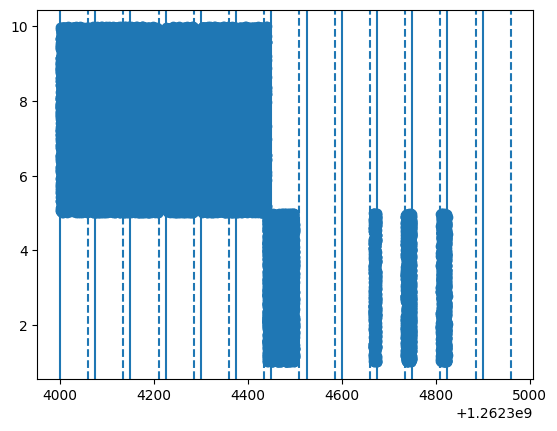

In [16]:
import matplotlib.pyplot as plt
plt.scatter(event_times, event_energies)
for i in range(len(gti_starts)):
    plt.axvline(gti_starts[i])
    plt.axvline(gti_stops[i],ls='dashed')

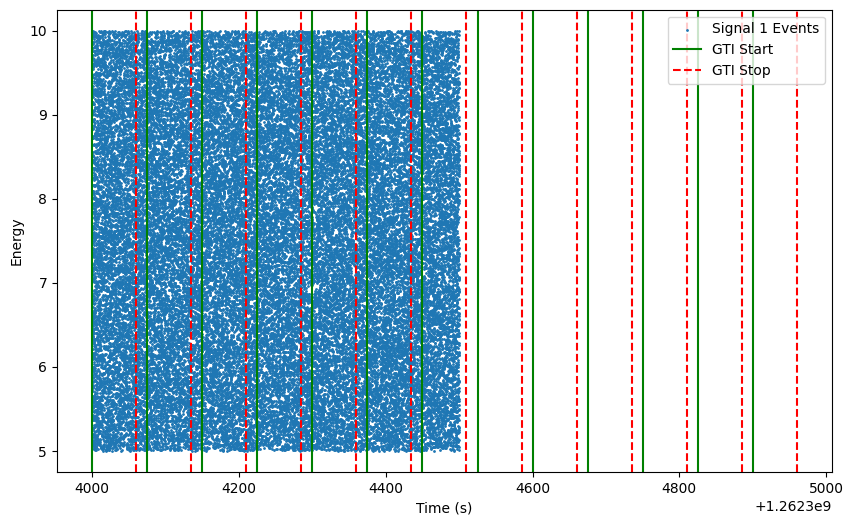

In [19]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 1000  # Total duration of the dataset in seconds
signal_frequency1 = 0.001  # Frequency of the primary signal in Hz
signal_frequency2 = 0.003  # Frequency of the secondary signal in Hz
sampling_rate = 100  # Number of events per second
noise_level = 0.5  # Noise level for the event times
primary_signal_duration = 60  # Duration of the primary signal intervals
secondary_signal_duration = 15  # Duration of the secondary signal intervals

# Energy ranges for signals
primary_energy_range = (5, 10)  # Energy range for the primary signal
secondary_energy_range = (1, 5)  # Energy range for the secondary signal

# Generate time array
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)

# Generate signals
primary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration),
     start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration)
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

secondary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration,
     start_time + (i + 1) * (primary_signal_duration + secondary_signal_duration))
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

# Create masks for Signal 1 in both primary and secondary intervals
primary_mask = np.zeros_like(time, dtype=bool)

# Apply masks for primary intervals (Signal 1 is active here)
for start, stop in primary_intervals:
    primary_mask |= (time >= start) & (time < stop)

# Create secondary mask (Signal 1 is active in gaps between primary_intervals)
secondary_mask = np.zeros_like(time, dtype=bool)
for i in range(len(primary_intervals) - 1):  # Gaps between primary intervals
    stop = primary_intervals[i][1]
    next_start = primary_intervals[i + 1][0]
    secondary_mask |= (time >= stop) & (time < next_start)

# Signal 1 is active in both primary and secondary intervals
signal1_mask = primary_mask | secondary_mask

# Generate Signal 1 (Sinusoidal signal)
signal1 = (
    np.sin(2 * np.pi * signal_frequency1 * (time - start_time)) > 0
) & signal1_mask

# Collect event times for Signal 1
event_times = time[signal1] + np.random.uniform(-noise_level, noise_level, size=sum(signal1))

# Assign energies to Signal 1
event_energies = np.random.uniform(primary_energy_range[0], primary_energy_range[1], size=len(event_times))

# Generate random RA and Dec values
event_ras = np.random.uniform(0, 360, size=len(event_times))
event_decs = np.random.uniform(-90, 90, size=len(event_times))

# Plot Signal 1 events
plt.figure(figsize=(10, 6))
plt.scatter(event_times, event_energies, s=1, label="Signal 1 Events")

# Overlay GTIs for primary intervals
for i in range(len(primary_intervals)):
    plt.axvline(primary_intervals[i][0], color="green", linestyle="-", label="GTI Start" if i == 0 else "")
    plt.axvline(primary_intervals[i][1], color="red", linestyle="--", label="GTI Stop" if i == 0 else "")

plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.legend()
plt.show()



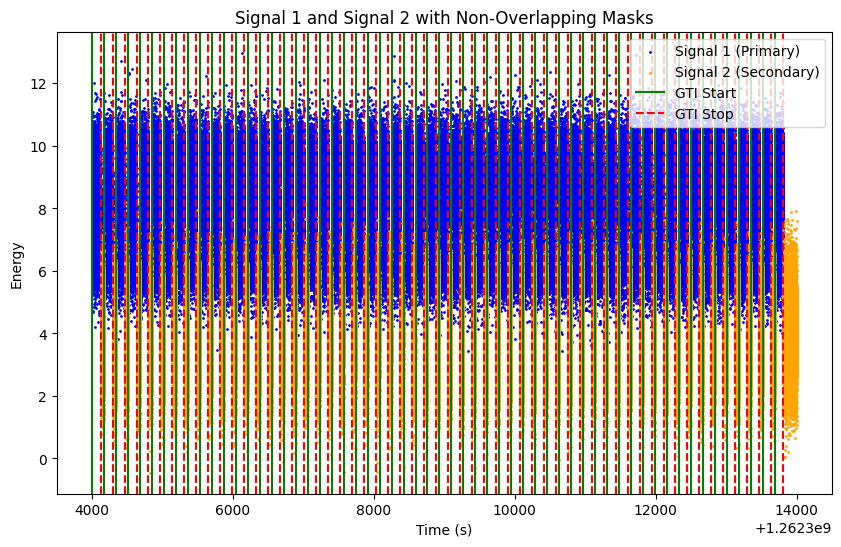

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 10000  # Total duration of the dataset in seconds
sampling_rate = 100  # Number of events per second
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)

# Signal parameters
signal_frequency1 = 0.001  # Frequency of Signal 1 in Hz
signal_frequency2 = 0.003  # Frequency of Signal 2 in Hz

# Energy parameters
energy1_mean, energy1_std = 8, 1  # Mean and std dev for Signal 1 energies
energy2_mean, energy2_std = 4, 1  # Mean and std dev for Signal 2 energies

# Generate full Signal 1 and Signal 2 over the whole time range
signal1 = np.sin(2 * np.pi * signal_frequency1 * (time - start_time)) > 0
signal2 = np.sin(2 * np.pi * signal_frequency2 * (time - start_time)) > 0

# Assign energies
signal1_energies = np.random.normal(energy1_mean, energy1_std, size=len(time))
signal2_energies = np.random.normal(energy2_mean, energy2_std, size=len(time))

# Define primary intervals (GTIs)
primary_signal_duration = 120  # Duration of primary signal intervals
secondary_signal_duration = 50  # Duration of secondary signal intervals

primary_intervals = [
    (start_time + i * (primary_signal_duration + secondary_signal_duration),
     start_time + i * (primary_signal_duration + secondary_signal_duration) + primary_signal_duration)
    for i in range(total_time // (primary_signal_duration + secondary_signal_duration))
]

# Create a mask for the primary intervals
primary_mask = np.zeros_like(time, dtype=bool)
for start, stop in primary_intervals:
    primary_mask |= (time >= start) & (time < stop)

# Mask Signal 1 to only be present in primary intervals
signal1_masked = signal1 & primary_mask

# Apply the inverse mask to Signal 2
signal2_masked = signal2 & ~primary_mask

# Collect events for Signal 1 and Signal 2
event_times1 = time[signal1_masked]
event_times2 = time[signal2_masked]

event_energies1 = signal1_energies[signal1_masked]
event_energies2 = signal2_energies[signal2_masked]

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(event_times1, event_energies1, color="blue", s=1, label="Signal 1 (Primary)")
plt.scatter(event_times2, event_energies2, color="orange", s=1, label="Signal 2 (Secondary)")

# Overlay GTIs
for start, stop in primary_intervals:
    plt.axvline(start, color="green", linestyle="-", label="GTI Start" if start == primary_intervals[0][0] else "")
    plt.axvline(stop, color="red", linestyle="--", label="GTI Stop" if start == primary_intervals[0][0] else "")

plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.legend()
plt.title("Signal 1 and Signal 2 with Non-Overlapping Masks")
plt.show()


200689
[1.26230400e+09 1.26230400e+09 1.26230400e+09 ... 1.26240399e+09
 1.26240399e+09 1.26240399e+09]
200077
[1.26230400e+09 1.26230400e+09 1.26230400e+09 ... 1.26240399e+09
 1.26240399e+09 1.26240399e+09]
       time              energy      
------------------ ------------------
1262304000.0289643  2.711063878656178
1262304000.3202906  2.684739865276608
1262304000.4709184  4.390079248176642
1262304001.0481014  3.282684661558816
 1262304001.433216  3.726104861049759
1262304001.4578028  4.119234854957147
 1262304002.859956  4.030102285059701
1262304003.6648018 2.0919687194340018
1262304004.7013292   4.50323981869881
1262304005.0960987 2.4662467716339953
               ...                ...
 1262402996.126436  6.903935846727614
 1262402996.212301  5.659868077671498
1262402997.0918095  9.861858778108921
1262402997.1121907  5.786310220805484
 1262402997.142446  6.936793127509448
1262402997.8397667  5.633125490274634
1262402997.9787111  9.052365424335814
1262402998.0642693  9.8942992039

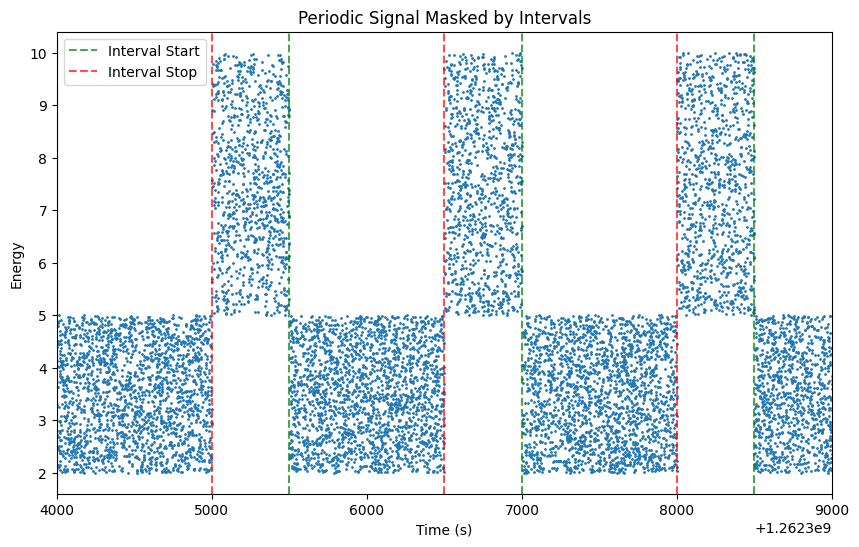

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from stingray.events import EventList
from stingray import Lightcurve
from astropy.table import Table


# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 100000  # Total duration of the dataset in seconds
signal_frequency1 = 2  # Frequency of the primary signal in Hz
signal_frequency2 = 0.35  # Frequency of the secondary signal in Hz
sampling_rate = 1000  # Number of events per second
noise_level = 0.5  # Noise level for the event times


# Parameters
#time_start = 0  # Start time in seconds
#time_end = 300  # End time in seconds
#sampling_rate = 10  # Number of samples per second
interval_width = 1000  # Width of each interval in seconds
gap_width = 500  # Width of each gap in seconds
amplitude = 1
base = 2

# Generate random signal data over the entire timescale
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)

rates1 = amplitude * np.sin(2 * np.pi * signal_frequency1 * time) + base
rates2 = amplitude * np.sin(2 * np.pi * signal_frequency2 * time) + base


# Create intervals
intervals = []
current_time = start_time
while current_time < start_time + total_time:
    start = current_time
    stop = current_time + interval_width
    if stop > start_time + total_time:
        break
    intervals.append([start, stop])
    current_time = stop + gap_width

intervals = np.array(intervals)


# IMPORTANT PART HERE!!!
lc1 = Lightcurve(time,rates1, input_counts=False)
events1 = EventList()
events1.simulate_times(lc1)
print(len(events1.time))
print(events1.time)
event_times1 = events1.time
event_energies1 = np.random.uniform(2, 5, size=len(event_times1))

lc2 = Lightcurve(time,rates2, input_counts=False)
events2 = EventList()
events2.simulate_times(lc2)
print(len(events2.time))
print(events2.time)
event_times2 = events2.time
event_energies2 = np.random.uniform(5, 10, size=len(event_times2))

# Mask the data to only include times within the intervals
event_mask1 = np.zeros_like(event_times1, dtype=bool)
for start, stop in intervals:
    event_mask1 |= (event_times1 >= start) & (event_times1 < stop)

# Mask the data to only include times within the intervals
event_mask2 = np.zeros_like(event_times2, dtype=bool)
for start, stop in intervals:
    event_mask2 |= (event_times2 >= start) & (event_times2 < stop)

combined_event_times = np.concatenate((event_times1[event_mask1], event_times2[~event_mask2]))
combined_event_energies = np.concatenate((event_energies1[event_mask1], event_energies2[~event_mask2]))

# Create Astropy Table for the combined event list
event_table = Table([combined_event_times, combined_event_energies], names=('time', 'energy'))
print(event_table)

# Save to HDF5
event_table.write("multi_signal_eventlist.hdf5", format="hdf5", path="event_list", overwrite=True)

# Create Astropy Table for intervals (GTI list)
interval_table = Table([intervals[:, 0], intervals[:, 1]], names=('gti_start', 'gti_stop'))
print(interval_table)
# Save intervals to HDF5
interval_table.write("primary_signal_gtilist.hdf5", format="hdf5", path="gti_list", overwrite=True)

print("Event list and GTI list successfully written to HDF5 files.")

# Plot the original and masked data
plt.figure(figsize=(10, 6))
#plt.scatter(time, rates, color="gray", s=1, alpha=0.5, label="Original Data")
#plt.scatter(event_times1[event_mask1], event_energies1[event_mask1], color="blue", s=1, label="Masked Data (Within Intervals)")
#plt.scatter(event_times2[~event_mask2], event_energies2[~event_mask2], color="blue", s=1, label="Masked Data (Within Intervals)")
plt.scatter(combined_event_times,combined_event_energies,s=1)
for start, stop in intervals:
    plt.axvline(start, color="green", linestyle="--", alpha=0.7, label="Interval Start" if start == intervals[0, 0] else "")
    plt.axvline(stop, color="red", linestyle="--", alpha=0.7, label="Interval Stop" if start == intervals[0, 0] else "")

plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.legend()
plt.title("Periodic Signal Masked by Intervals")
plt.xlim([start_time,start_time+5000])
plt.show()


199797
[1.26230400e+09 1.26230400e+09 1.26230400e+09 ... 1.26240399e+09
 1.26240399e+09 1.26240399e+09]
       time              energy      
------------------ ------------------
1262304000.6277654  4.293960330505552
1262304000.9337482 3.5472472664613264
1262304001.3264904 2.1252828596981725
1262304002.4758887 4.1001941997909555
 1262304002.540258 3.2519358311745608
1262304002.8635838  2.550758547965512
1262304005.0398443   3.46611337470701
 1262304005.566199 2.2944559663525115
1262304005.5991325  4.107104204326293
1262304006.4226954  2.065703270351414
               ...                ...
 1262403985.105738  2.654069626180791
 1262403985.664846 2.9395340572342388
1262403986.8149042  2.784960885585169
1262403986.9616847 3.5070195206738286
 1262403987.208705 3.9356399542063447
1262403988.0862784  3.400076210628519
1262403989.2534425 2.2868715972052294
1262403991.1699677 2.0818846502062245
1262403991.5098925  4.432316501011951
1262403992.1223047 3.1382311904468043
1262403992.2445242  4.

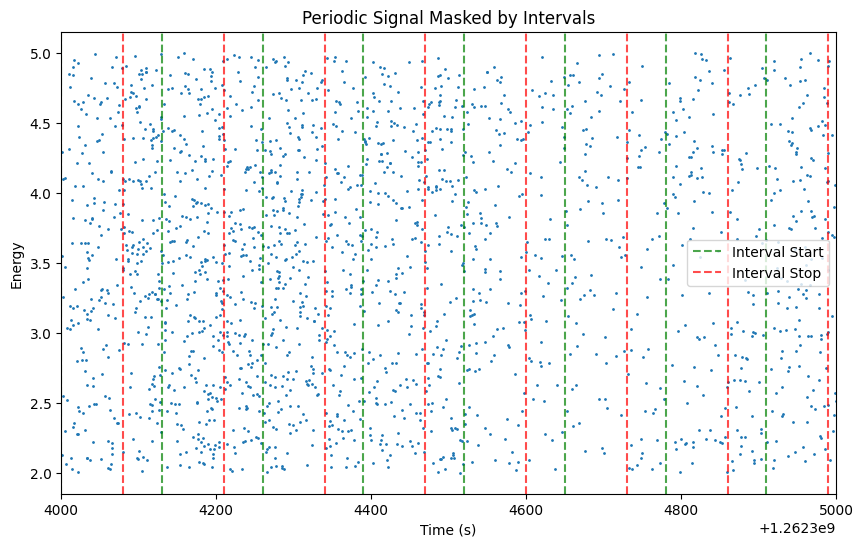

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from stingray.events import EventList
from stingray import Lightcurve
from astropy.table import Table


# Parameters for the data
start_time = 1262304000  # Unix timestamp for January 1, 2010
total_time = 100000  # Total duration of the dataset in seconds
signal_frequency1 = 0.001  # Frequency of the primary signal in Hz
signal_frequency2 = 0.003  # Frequency of the secondary signal in Hz
sampling_rate = 1000  # Number of events per second
noise_level = 0.5  # Noise level for the event times


# Parameters
#time_start = 0  # Start time in seconds
#time_end = 300  # End time in seconds
#sampling_rate = 10  # Number of samples per second
interval_width = 80  # Width of each interval in seconds
gap_width = 50  # Width of each gap in seconds
amplitude = 1
base = 2

# Generate random signal data over the entire timescale
time = np.arange(start_time, start_time + total_time, 1 / sampling_rate)

rates1 = amplitude * np.sin(2 * np.pi * signal_frequency1 * time) + base


# IMPORTANT PART HERE!!!
lc1 = Lightcurve(time,rates1, input_counts=False)
events1 = EventList()
events1.simulate_times(lc1)
print(len(events1.time))
print(events1.time)
event_times1 = events1.time
event_energies1 = np.random.uniform(2, 5, size=len(event_times1))




combined_event_times = np.array(event_times1) #np.concatenate((event_times1[event_mask1], event_times2[~event_mask2]))
combined_event_energies = np.array(event_energies1) #np.concatenate((event_energies1[event_mask1], event_energies2[~event_mask2]))

# Create Astropy Table for the combined event list
event_table = Table([combined_event_times, combined_event_energies], names=('time', 'energy'))
print(event_table)

# Save to HDF5
event_table.write("single_signal_eventlist.hdf5", format="hdf5", path="event_list", overwrite=True)

print("Event list successfully written to HDF5 file.")

# Plot the original and masked data
plt.figure(figsize=(10, 6))
#plt.scatter(time, rates, color="gray", s=1, alpha=0.5, label="Original Data")
#plt.scatter(event_times1[event_mask1], event_energies1[event_mask1], color="blue", s=1, label="Masked Data (Within Intervals)")
#plt.scatter(event_times2[~event_mask2], event_energies2[~event_mask2], color="blue", s=1, label="Masked Data (Within Intervals)")
plt.scatter(combined_event_times,combined_event_energies,s=1)
for start, stop in intervals:
    plt.axvline(start, color="green", linestyle="--", alpha=0.7, label="Interval Start" if start == intervals[0, 0] else "")
    plt.axvline(stop, color="red", linestyle="--", alpha=0.7, label="Interval Stop" if start == intervals[0, 0] else "")

plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.legend()
plt.title("Periodic Signal Masked by Intervals")
plt.xlim([start_time,start_time+1000])
plt.show()